In [1]:
# Logistic Regression end-to-end example with diagnostics and evaluation
# Dataset: Breast Cancer (binary classification)
#
# This script:
# - Loads and inspects the data
# - Splits train/test (stratified)
# - Builds a Pipeline: StandardScaler + LogisticRegressionCV (L2)
# - Evaluates with accuracy, ROC-AUC, PR-AUC, F1, Brier score
# - Plots ROC, Precision-Recall, and Calibration curves
# - Tunes threshold for best F1 and shows confusion matrices
# - Shows coefficients (with odds ratios) and top features
# - Checks multicollinearity via VIF
#
# Charts follow the tool rules: matplotlib only, no seaborn, one chart per figure, no custom colors.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    precision_recall_fscore_support, confusion_matrix, brier_score_loss,
    roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.compose import ColumnTransformer


# 1) Load dataset

In [ ]:

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")  # 1 = malignant? Let's confirm: In this dataset, target 0=malignant, 1=benign
target_names = data.target_names
# For clarity, map target to strings as well (not used in modeling)
label_map = {0: "malignant", 1: "benign"}
y_text = y.map(label_map)


# 2) train pipeline

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Pipeline with StandardScaler + LogisticRegressionCV
# We'll use saga solver to support larger C grid efficiently; 5-fold CV on AUC.
Cs = np.logspace(-3, 3, 13)  # 1e-3 to 1e3
logreg_cv = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegressionCV(
        Cs=Cs, #Cs parameter refers to the inverse of regularization strength, and it is a key hyperparameter for controlling the model's complexity during cross-validation.
        cv=5,
        scoring="roc_auc",
        penalty="l2",
        solver="lbfgs",  # lbfgs is fine for l2
        max_iter=5000,
        n_jobs=-1,
        fit_intercept=True,
        refit=True,
    ))
])

logreg_cv.fit(X_train, y_train)
clf = logreg_cv.named_steps["clf"]

In [9]:
logreg_cv.named_steps["clf"]

,Cs,array([1.0000...00000000e+03])
,fit_intercept,True
,cv,5
,dual,False
,penalty,'l2'
,scoring,'roc_auc'
,solver,'lbfgs'
,tol,0.0001
,max_iter,5000
,class_weight,None
,n_jobs,-1


# 3) Predictions and metrics


In [41]:

proba_test = logreg_cv.predict_proba(X_test) # probability of class 1 (benign)
pred_default = (proba_test[:, 1]  >= 0.5).astype(int)

In [43]:
acc = accuracy_score(y_test, pred_default)
roc_auc = roc_auc_score(y_test, proba_test[:, 1] )
pr_auc = average_precision_score(y_test, proba_test[:, 1] )
brier = brier_score_loss(y_test, proba_test[:, 1] )

prec, rec, f1, _ = precision_recall_fscore_support(y_test, pred_default, average="binary")

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "ROC AUC", "PR AUC (Avg Precision)", "F1", "Brier Score"],
    "Value": [acc, roc_auc, pr_auc, f1, brier]
})

print("Logistic Regression: Key Test Metrics")
metrics_df.round(4)

Logistic Regression: Key Test Metrics


,Metric,Value
0,Accuracy,0.9790
1,ROC AUC,0.9971
2,PR AUC (Avg Precision),0.9983
3,F1,0.9834
4,Brier Score,0.0264


# 4) Threshold tuning for best F1

In [16]:

precisions, recalls, thresholds_pr = precision_recall_curve(y_test, proba_test)
f1s = (2 * precisions * recalls) / (precisions + recalls + 1e-12)
best_idx = np.nanargmax(f1s)
best_f1 = f1s[best_idx]

In [19]:
# precision_recall_curve returns thresholds shorter by 1 than precisions/recalls; handle that:
best_threshold = thresholds_pr[max(best_idx - 1, 0)] if best_idx > 0 else 0.5

pred_best = (proba_test >= best_threshold).astype(int)
acc_best = accuracy_score(y_test, pred_best)
prec_best, rec_best, f1_best, _ = precision_recall_fscore_support(y_test, pred_best, average="binary")

In [ ]:
cm_default = confusion_matrix(y_test, pred_default)
cm_best = confusion_matrix(y_test, pred_best)

thr_df = pd.DataFrame({
    "Setting": ["Default 0.5", f"Best F1 @ {best_threshold:.3f}"],
    "Accuracy": [acc, acc_best],
    "Precision": [prec, prec_best],
    "Recall": [rec, rec_best],
    "F1": [f1, f1_best]
})

thr_df.round(4)


,Setting,Accuracy,Precision,Recall,F1
0,Default 0.5,0.979,0.978,0.9889,0.9834
1,Best F1 @ 0.519,0.979,0.978,0.9889,0.9834


# 5) Plots: ROC, PR, Calibration


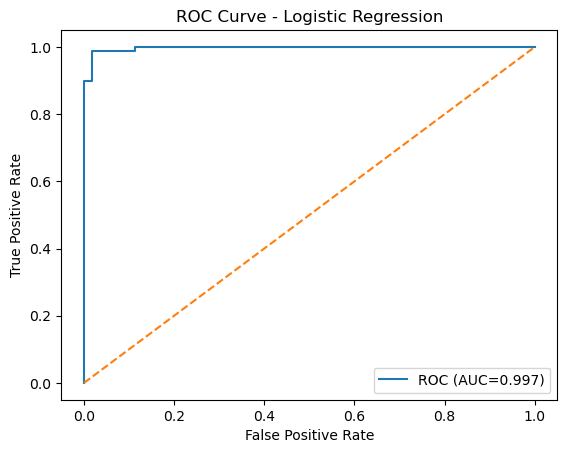

In [21]:

# ROC
fpr, tpr, _ = roc_curve(y_test, proba_test)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.show()

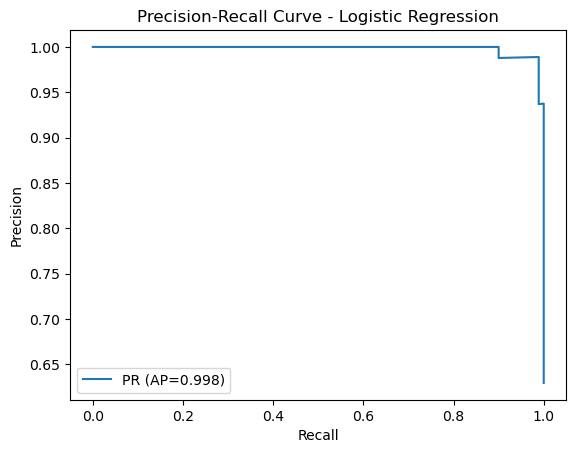

In [22]:
# PR
plt.figure()
plt.plot(recalls, precisions, label=f"PR (AP={pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.legend(loc="lower left")
plt.show()

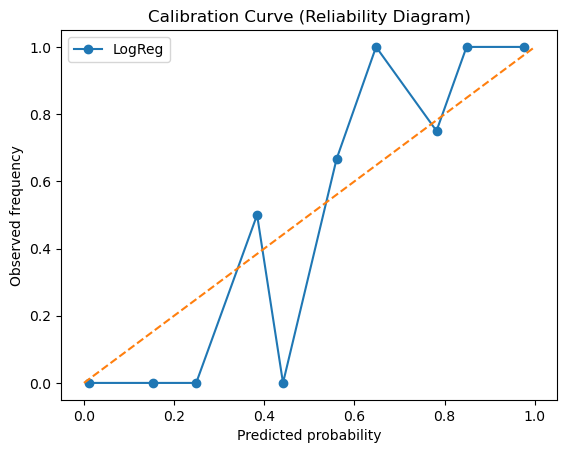

In [23]:
# Calibration / reliability curve
prob_true, prob_pred = calibration_curve(y_test, proba_test, n_bins=10, strategy="uniform")
plt.figure()
plt.plot(prob_pred, prob_true, marker="o", label="LogReg")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve (Reliability Diagram)")
plt.legend(loc="upper left")
plt.show()

# 6) Coefficients and odds ratios

In [ ]:
coef = clf.coef_.ravel()  # shape (n_features,)
intercept = clf.intercept_[0]
features = X.columns

coef_df = pd.DataFrame({
    "feature": features,
    "coef": coef,
    "odds_ratio": np.exp(coef)
}).sort_values(by="coef", ascending=False)
coef_df.round(4)


,feature,coef,odds_ratio
15,compactness error,0.2184,1.2441
19,fractal dimension error,0.2071,1.2301
9,mean fractal dimension,0.1729,1.1888
18,symmetry error,0.1680,1.1829
16,concavity error,0.0858,1.0896
11,texture error,0.0602,1.0620
5,mean compactness,-0.0001,0.9999
14,smoothness error,-0.0173,0.9828
29,worst fractal dimension,-0.1326,0.8758
8,mean symmetry,-0.1400,0.8694


In [26]:
# Top positive/negative features
top_pos = coef_df.head(10).copy()
top_neg = coef_df.tail(10).copy()

print("Top 10 Positive (Benign-likely) Features", top_pos.round(4))
print("Top 10 Negative (Malignant-likely) Features", top_neg.round(4))

Top 10 Positive (Benign-likely) Features                     feature    coef  odds_ratio
15        compactness error  0.2184      1.2441
19  fractal dimension error  0.2071      1.2301
9    mean fractal dimension  0.1729      1.1888
18           symmetry error  0.1680      1.1829
16          concavity error  0.0858      1.0896
11            texture error  0.0602      1.0620
5          mean compactness -0.0001      0.9999
14         smoothness error -0.0173      0.9828
29  worst fractal dimension -0.1326      0.8758
8             mean symmetry -0.1400      0.8694
Top 10 Negative (Malignant-likely) Features                  feature    coef  odds_ratio
7    mean concave points -0.3956      0.6733
0            mean radius -0.3992      0.6709
28        worst symmetry -0.4077      0.6652
10          radius error -0.4290      0.6511
1           mean texture -0.4334      0.6483
23            worst area -0.4440      0.6415
22       worst perimeter -0.4448      0.6409
27  worst concave points -0

# 7) Multicollinearity (VIF) on scaled data

In [27]:
# Extract standardized coefficients from the fitted pipeline
scaler = logreg_cv.named_steps["scaler"]
X_train_scaled = scaler.transform(X_train)
# Compute VIF requires no intercept column; use scaled train set matrix.
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=features)
vifs = []
for i in range(X_train_scaled_df.shape[1]):
    vifs.append(variance_inflation_factor(X_train_scaled_df.values, i))
vif_df = pd.DataFrame({"feature": features, "VIF": vifs}).sort_values("VIF", ascending=False)
print("Variance Inflation Factors (VIF)", vif_df.round(3))

Variance Inflation Factors (VIF)                     feature       VIF
0               mean radius  3861.185
2            mean perimeter  3859.567
20             worst radius   765.029
22          worst perimeter   381.643
3                 mean area   352.741
23               worst area   315.588
12          perimeter error    72.912
6            mean concavity    70.891
10             radius error    67.074
7       mean concave points    63.249
5          mean compactness    58.324
13               area error    43.974
27     worst concave points    40.028
25        worst compactness    39.833
26          worst concavity    34.513
29  worst fractal dimension    19.040
21            worst texture    18.550
16          concavity error    18.348
9    mean fractal dimension    16.490
15        compactness error    16.109
17     concave points error    14.390
1              mean texture    12.160
19  fractal dimension error    10.699
28           worst symmetry    10.624
24         worst 

# 8) Confusion matrices display as small dataframes


In [28]:
cm_default_df = pd.DataFrame(cm_default, index=["Actual 0 (malignant)", "Actual 1 (benign)"],
                             columns=["Pred 0 (malignant)", "Pred 1 (benign)"])
cm_best_df = pd.DataFrame(cm_best, index=["Actual 0 (malignant)", "Actual 1 (benign)"],
                          columns=["Pred 0 (malignant)", "Pred 1 (benign)"])
print("Confusion Matrix @ Threshold 0.5", cm_default_df)
print(f"Confusion Matrix @ Best F1 Threshold ({best_threshold:.3f})", cm_best_df)

Confusion Matrix @ Threshold 0.5                       Pred 0 (malignant)  Pred 1 (benign)
Actual 0 (malignant)                  51                2
Actual 1 (benign)                      1               89
Confusion Matrix @ Best F1 Threshold (0.519)                       Pred 0 (malignant)  Pred 1 (benign)
Actual 0 (malignant)                  51                2
Actual 1 (benign)                      1               89


# 9) Brief feature effect visualization (single-feature logit curves) for 2 strong features

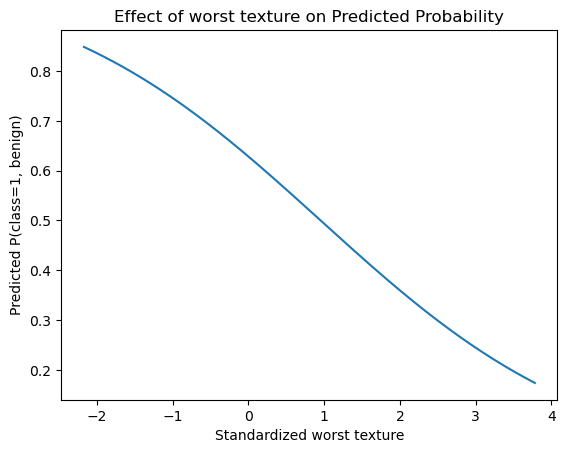

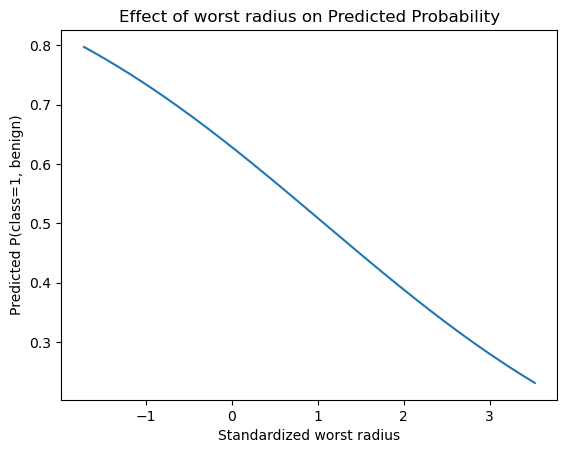

Done. The tables above summarize metrics, thresholds, coefficients, and VIF. Plots show ROC, PR, calibration, and two single-feature effects.


In [ ]:



# For logistic regression, decision function is linear in standardized features.
# We'll visualize the relationship between a single standardized feature and predicted probability, holding others at mean (0 after scaling).
def plot_single_feature_effect(feature_name):
    idx = list(features).index(feature_name)
    x_vals = np.linspace(X_train_scaled_df[feature_name].min(), X_train_scaled_df[feature_name].max(), 200)
    # decision = intercept + sum_j coef_j * x_j ; with others at 0 => decision = intercept + coef_idx * x
    decision = intercept + coef[idx] * x_vals
    probs = 1 / (1 + np.exp(-decision))
    plt.figure()
    plt.plot(x_vals, probs)
    plt.xlabel(f"Standardized {feature_name}")
    plt.ylabel("Predicted P(class=1, benign)")
    plt.title(f"Effect of {feature_name} on Predicted Probability")
    plt.show()

# Pick two features with high absolute coefficients
strong_features = coef_df.reindex(coef_df["coef"].abs().sort_values(ascending=False).index)["feature"].head(2).tolist()
for feat in strong_features:
    plot_single_feature_effect(feat)

print("Done. The tables above summarize metrics, thresholds, coefficients, and VIF. Plots show ROC, PR, calibration, and two single-feature effects.")
